# Grouping Comparison Experiment

Compares five alert-grouping methods (fixed window, time-delta, CSCAS-style,
AlertBERT, DeepCASE) on the held-out test scenarios (`fox`,
`russellmitchell`): alert volume reduction, group size distribution, group
purity, and (DeepCASE only) the fraction of alerts rejected outright rather
than grouped (`ungroupable_fraction`).

Each method's sweep now runs as its own standalone script
(`src/thesis/baselines/grouping/*.py`) rather than inline in this notebook
-- this notebook only loads their `results/*.json` (+ `*_sizes.npz`)
artifacts and plots them. See `run_grouping.sh` in that directory to run
every script overnight; the `GROUPING_DEVICE` env var selects `mps`/`cuda`/
`cpu` (default: auto-detect) for the two torch-based methods.

**Run the scripts first** to generate the artifacts this notebook reads:
```
cd src/thesis/baselines/grouping
python fixed_window.py
python time_delta.py
python cscas_grouping.py
python cscas_grouping_sensitivity.py
python deepcase_sweep.py
```
`alertbert_sweep.py` needs the separate `thesis-alertbert` conda env
(`alertbert.models` hard-imports `graph_tool`, not part of this project's
plain `venv/`):
```
conda activate thesis-alertbert
KMP_DUPLICATE_LIB_OK=TRUE python alertbert_sweep.py
```
This notebook itself only needs the plain venv -- it never imports
`thesis.grouping`/`torch`/`alertbert`/`deepcase`.


## 1. Imports

In [25]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from thesis.baselines.grouping._results import (
    load_grouping_results,
    load_group_size_arrays,
)

## 2. Settings

Edit and re-run -- nothing past this cell needs to change.


In [26]:
# The 5 methods that feed the shared cross-method comparison (each has a
# results/{name}.json + results/{name}_sizes.npz, written by the
# like-named script in src/thesis/baselines/grouping/).
GROUPING_RESULT_NAMES = ["fixed_window", "time_delta", "cscas_grouping", "alertbert", "deepcase"]

# CSCAS's authors' own validated production settings -- must match the
# primary config baked into cscas_grouping.py/cscas_grouping_sensitivity.py.
# Only used here for the sensitivity plot's reference lines.
CSCAS_SESSION_LENGTH_SECONDS = 300.0
CSCAS_SESSION_TIMEOUT_SECONDS = 60.0

# Shared across every scenario-aware plot below so "fox" reads as the same
# color/marker everywhere in this notebook.
SCENARIO_COLORS = {"fox": "#4477AA", "russellmitchell": "#EE6677"}
SCENARIO_MARKERS = {"fox": "o", "russellmitchell": "^"}


## 3. Loading

Tolerant of missing artifacts (prints `[skip] ...` and continues) -- run
whichever scripts you have, this notebook plots whatever's available.


In [27]:
results_dfs: dict[str, pd.DataFrame] = {}
size_arrays: dict[tuple, np.ndarray] = {}
for name in GROUPING_RESULT_NAMES:
    try:
        results_dfs[name] = load_grouping_results(name)
        size_arrays.update(load_group_size_arrays(name))
    except FileNotFoundError as e:
        print(f"[skip] {e}")

print(f"Loaded results for: {list(results_dfs.keys())}")

# Derived columns needed by the per-method diagnostic plots below -- moved
# here from what used to be inline sweep cells.
if "time_delta" in results_dfs:
    results_dfs["time_delta"]["delta"] = results_dfs["time_delta"]["param"].astype(float)
if "deepcase" in results_dfs:
    results_dfs["deepcase"]["context_length"] = (
        results_dfs["deepcase"]["param"].str.extract(r"L=(\d+)").astype(int)
    )
    results_dfs["deepcase"]["eps"] = (
        results_dfs["deepcase"]["param"].str.extract(r"eps=([\d.]+)").astype(float)
    )
if "alertbert" in results_dfs:
    results_dfs["alertbert"]["delta"] = (
        results_dfs["alertbert"]["param"].str.extract(r"d=([\d.]+)").astype(float)
    )
    results_dfs["alertbert"]["theta"] = (
        results_dfs["alertbert"]["param"].str.extract(r"t=([\d.]+)").astype(float)
    )

all_results_df = (
    pd.concat(results_dfs.values(), ignore_index=True) if results_dfs else pd.DataFrame()
)

try:
    cscas_sensitivity_df = load_grouping_results("cscas_grouping_sensitivity")
except FileNotFoundError as e:
    print(f"[skip] {e}")
    cscas_sensitivity_df = pd.DataFrame()

try:
    manual_review_df = load_grouping_results("deepcase_manual_review")
except FileNotFoundError as e:
    print(f"[skip] {e}")
    manual_review_df = pd.DataFrame()


Loaded results for: ['fixed_window', 'time_delta', 'cscas_grouping', 'alertbert', 'deepcase']


/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_68805/2890516554.py:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat(results_dfs.values(), ignore_index=True) if results_dfs else pd.DataFrame()


## 3b. Per-setting results table (helper)

`settings_table` is used at the end of every method section (4–8). It
reports, for **each setting tested** (every swept configuration × scenario,
and — where the method has one — the global vs. per-host variant; *not* the
single jointly-best operating point picked later in section 9):

| column | meaning |
|---|---|
| `reduction` | alert volume reduction — proportion of alerts that no longer need individual review, per scenario and host variant |
| `group_size_mean` / `_median` / `_max` | alerts per group; the median and max are shown alongside the mean because a method can post a high reduction simply by emitting one enormous group |
| `pure_benign_frac` / `pure_attack_frac` / `mixed_frac` | fraction of groups that are pure-benign, pure-attack, or mixed, by AIT-ADS label |

These tables are the numeric backing for the diagnostic plots above them;
they do not feed `all_results_df` or the section 9 comparison.

Every method section (4–8) and every cross-method table (9–11) also prints a
**`booktabs` LaTeX version** of its table for pasting straight into the
thesis (helper `to_latex_table`, section 3c) — nothing is written to disk.

In [28]:
# Columns every end-of-section table reports, in order: alert volume
# reduction; group size mean/median/max (not the mean alone -- one runaway
# group inflates reduction by itself); group purity as the pure-benign /
# pure-attack / mixed group fractions from AIT-ADS labels.
PER_SETTING_METRICS = [
    "reduction",
    "group_size_mean",
    "group_size_median",
    "group_size_max",
    "pure_benign_frac",
    "pure_attack_frac",
    "mixed_frac",
]

_PER_SETTING_ROUNDING = {
    "reduction": 4,
    "group_size_mean": 1,
    "group_size_median": 1,
    "pure_benign_frac": 4,
    "pure_attack_frac": 4,
    "mixed_frac": 4,
}


def settings_table(
    df: pd.DataFrame,
    id_cols: list[str],
    sort_cols: list[str] | None = None,
    title: str = "",
    latex_caption: str = "",
    latex_label: str = "",
    latex_longtable: bool = False,
) -> pd.DataFrame:
    """
    Render one method section's per-setting results table -- one row per
    setting tested, columns PER_SETTING_METRICS (see section 3b).

    `id_cols` become the row index; `sort_cols` (default `id_cols`) order
    the rows and may name helper columns that aren't shown in the table
    itself (e.g. a numeric sort key for a string `param`). Returns the
    table and also displays it with every row visible.

    When `latex_caption` is given, a booktabs LaTeX version of the same
    table is also printed (via `to_latex_table`, defined in section 3c
    below -- only called at run time, so the forward reference is fine).
    Pass `latex_longtable=True` for the long sweeps (time-delta, AlertBERT,
    DeepCASE) so they page across a `longtable` rather than one `tabular`.
    """
    table = (
        df.sort_values(list(sort_cols or id_cols))
        .set_index(id_cols)[PER_SETTING_METRICS]
        .round(_PER_SETTING_ROUNDING)
    )
    if title:
        print(title)
    with pd.option_context("display.max_rows", None):
        display(table)
    if latex_caption:
        print(to_latex_table(
            table,
            caption=latex_caption,
            label=latex_label,
            longtable=latex_longtable,
        ))
    return table

## 3c. LaTeX table export

`to_latex_table(df, *, caption, label, ...)` renders a DataFrame as a
`booktabs` LaTeX table in the same house style as
`ait_ads_baseline_comparison.ipynb` / `cscas_baseline_comparison.ipynb` and
returns the string. Every table section below prints its LaTeX right after
the rendered DataFrame; nothing is written to disk.

**Preamble the output assumes:** `\usepackage{booktabs}` throughout;
`\usepackage{graphicx}` for the wide section 9 / 11 tables (wrapped in
`\resizebox`); `\usepackage{longtable}` for the long per-setting sweeps
(time-delta, AlertBERT, DeepCASE). Column headers are prettified and
per-column decimal places are set via `_LATEX_COL_RENAME` /
`_LATEX_COL_DECIMALS` — edit those to taste.

In [ ]:
import re


_LATEX_NA = "--"
_NUMERIC_STR = re.compile(r"^-?\d+(?:\.\d+)?$")

# Pretty headers for column / index-level names. Anything not listed is used
# verbatim, with LaTeX specials escaped.
_LATEX_COL_RENAME = {
    "reduction": "Reduction", "reduction_mean": "Reduction", "coverage": "Coverage",
    "group_size_mean": "Size mean", "group_size_median": "Size med.",
    "group_size_max": "Size max", "n_groups": r"\#groups",
    "pure_benign_frac": "Pure-benign", "pure_attack_frac": "Pure-attack",
    "mixed_frac": "Mixed", "host_purity": "Host purity", "ungroupable_fraction": "Ungroupable",
    "signature_diversity_mean": "Sig.\\ div.", "temporal_span_mean": "Span (s)",
    "minority_label_exposure": "Minority exp.", "train_time_seconds": "Train (s)",
    "inference_time_seconds": "Infer (s)", "gap": "Gap", "gpu_required": "GPU",
    "extra_deps": "Extra deps", "has_rejection_path": "Rejects?",
    "passes_operational": "Op. fit", "passes_reduction": "G1", "passes_purity": "G2",
    "passes_generalization": "G3", "n_gates_passed": r"\#gates", "verdict": "Verdict",
    "authors_validated": "Authors' cfg", "context_length": "$L$",
    "eps": r"$\varepsilon$", "delta": r"$\delta$ (s)", "theta": r"$\theta$ (s)",
    "scenario": "Scenario", "method": "Method", "param": "Param", "setting": "Setting",
}
# Fixed decimal places per metric column; columns not listed use the call's
# `decimals` argument.
_LATEX_COL_DECIMALS = {
    "group_size_mean": 1, "group_size_median": 1, "group_size_max": 0, "n_groups": 0,
    "temporal_span_mean": 1, "signature_diversity_mean": 2, "train_time_seconds": 1,
    "inference_time_seconds": 2, "n_gates_passed": 0,
}


def _tex_escape(s) -> str:
    s = str(s)
    if "$" in s or "\\" in s:  # already math / a macro -- leave alone
        return s
    for a, b in (("\\", r"\textbackslash{}"), ("&", r"\&"), ("%", r"\%"),
                 ("#", r"\#"), ("_", r"\_"), ("{", r"\{"), ("}", r"\}"),
                 ("~", r"\textasciitilde{}"), ("^", r"\textasciicircum{}")):
        s = s.replace(a, b)
    return s


def _fmt_index(v) -> str:
    """Row-label cell: compact, no thousands separators, no forced decimals."""
    if v is None or (isinstance(v, float) and pd.isna(v)) or v is pd.NA:
        return _LATEX_NA
    if isinstance(v, (bool, np.bool_)):
        return "yes" if v else "no"
    if isinstance(v, str):
        return f"{float(v):g}" if _NUMERIC_STR.match(v.strip()) else _tex_escape(v)
    if isinstance(v, (int, np.integer)):
        return str(int(v))
    f = float(v)
    return str(int(f)) if f.is_integer() else f"{f:g}"


def _fmt_value(v, decimals: int) -> str:
    """Data cell: fixed `decimals`, thousands separators, NaN/None -> --."""
    if v is None or (isinstance(v, float) and pd.isna(v)) or v is pd.NA:
        return _LATEX_NA
    if isinstance(v, (bool, np.bool_)):
        return "yes" if v else "no"
    if isinstance(v, str):
        return _tex_escape(v)
    f = float(v)
    if not np.isfinite(f):
        return _LATEX_NA
    return f"{f:,.{decimals}f}"


def to_latex_table(df, *, caption: str, label: str, decimals: int = 3,
                   longtable: bool = False, resizebox: bool = False,
                   rename: bool = True, group_rule: bool = True) -> str:
    """
    Booktabs LaTeX for `df`, in the house style of the ait_ads / cscas
    baseline notebooks. Returns the string; the caller prints it.

    - MultiIndex row labels render as leading columns, repeats blanked, with
      a \\midrule between top-level groups (`group_rule`).
    - `decimals` is the default fixed decimal places for numeric cells;
      `_LATEX_COL_DECIMALS` overrides it per metric.
    - `longtable=True` -> a bare `longtable` (no float wrapper, no resizebox),
      for tables too long for one page.
    - `resizebox=True` -> scale a wide `tabular` to \\textwidth (needs graphicx).
    """
    d = df.to_frame() if isinstance(df, pd.Series) else df.copy()
    n_lvl = d.index.nlevels
    idx_names = list(d.index.names) if n_lvl > 1 else [d.index.name]
    idx_names = ["" if n is None else n for n in idx_names]

    def hdr(name):
        return _LATEX_COL_RENAME.get(name, _tex_escape(name)) if rename else _tex_escape(name)

    col_dec = [_LATEX_COL_DECIMALS.get(c, decimals) for c in d.columns]
    header = " & ".join([hdr(n) for n in idx_names] + [hdr(c) for c in d.columns]) + r" \\"
    col_fmt = "l" * n_lvl + "r" * len(d.columns)
    ncol = n_lvl + len(d.columns)

    body, prev = [], None
    for key, row in zip(d.index, d.itertuples(index=False, name=None)):
        kt = key if isinstance(key, tuple) else (key,)
        lead, diverged = [], False
        for i, val in enumerate(kt):
            if diverged or prev is None or prev[i] != kt[i]:
                lead.append(_fmt_index(val))
                diverged = True
            else:
                lead.append("")
        if group_rule and n_lvl > 1 and prev is not None and prev[0] != kt[0]:
            body.append(r"\midrule")
        body.append(" & ".join(lead + [_fmt_value(v, col_dec[j]) for j, v in enumerate(row)]) + r" \\")
        prev = kt

    if longtable:
        return "\n".join([
            rf"\begin{{longtable}}{{{col_fmt}}}",
            rf"\caption{{{caption}}}\label{{{label}}}\\",
            r"\toprule", header, r"\midrule", r"\endfirsthead",
            rf"\multicolumn{{{ncol}}}{{c}}{{\tablename\ \thetable\ (continued)}}\\",
            r"\toprule", header, r"\midrule", r"\endhead",
            r"\midrule",
            rf"\multicolumn{{{ncol}}}{{r}}{{\emph{{continued on next page}}}}\\",
            r"\endfoot", r"\bottomrule", r"\endlastfoot", *body, r"\end{longtable}",
        ])

    tab = "\n".join([rf"\begin{{tabular}}{{{col_fmt}}}", r"\toprule", header,
                     r"\midrule", *body, r"\bottomrule", r"\end{tabular}"])
    if resizebox:
        tab = "\\resizebox{\\textwidth}{!}{%\n" + tab + "%\n}"
    return "\n".join([r"\begin{table}[htbp]", r"\centering", r"\small",
                      rf"\caption{{{caption}}}", rf"\label{{{label}}}", tab,
                      r"\end{table}"])

## 4. Fixed window

Linear sweep (this method's parameter is an absolute group size, not a
gap threshold, so no log-scale sweep here — see the time-delta section
for why that distinction matters).


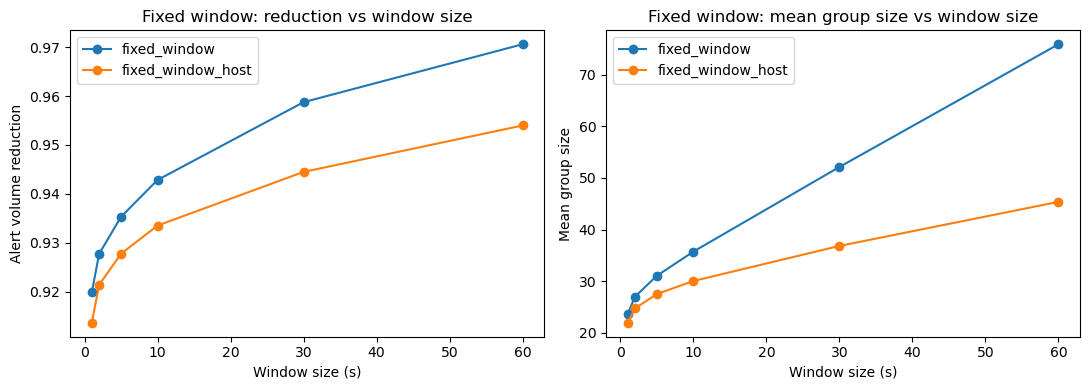

In [29]:
fixed_window_df = results_dfs.get("fixed_window")
if fixed_window_df is None:
    print("[skip] fixed_window not loaded -- run fixed_window.py first")
else:
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))

    for method_name, group in fixed_window_df.groupby("method"):
        agg = group.groupby("param", as_index=False)["reduction"].mean()
        agg["param"] = agg["param"].astype(int)
        agg = agg.sort_values("param")
        ax[0].plot(agg["param"], agg["reduction"], marker="o", label=method_name)

    ax[0].set_xlabel("Window size (s)")
    ax[0].set_ylabel("Alert volume reduction")
    ax[0].set_title("Fixed window: reduction vs window size")
    ax[0].legend()

    for method_name, group in fixed_window_df.groupby("method"):
        agg = group.groupby("param", as_index=False)["group_size_mean"].mean()
        agg["param"] = agg["param"].astype(int)
        agg = agg.sort_values("param")
        ax[1].plot(agg["param"], agg["group_size_mean"], marker="o", label=method_name)

    ax[1].set_xlabel("Window size (s)")
    ax[1].set_ylabel("Mean group size")
    ax[1].set_title("Fixed window: mean group size vs window size")
    ax[1].legend()

    plt.tight_layout()
    plt.show()


In [30]:
# Every fixed-window setting tested: both variants (global `fixed_window`,
# per-host `fixed_window_host`), all six window sizes, both scenarios.
if fixed_window_df is None:
    print("[skip] fixed_window not loaded -- run fixed_window.py first")
else:
    fixed_window_settings_table = settings_table(
        fixed_window_df.assign(window_s=lambda d: d["param"].astype(int)),
        id_cols=["scenario", "method", "param"],
        sort_cols=["scenario", "method", "window_s"],
        title="Fixed window -- every setting tested",
        latex_caption=(
            "Fixed-window grouping: every setting tested (global and per-host "
            "variant, all six window sizes, both held-out test scenarios)."
        ),
        latex_label="tab:grouping-fixed-window-settings",
    )

Fixed window -- every setting tested


reduction  group_size_mean  \
scenario        method            param                               
fox             fixed_window      1         0.9750             39.9   
                                  2         0.9782             45.9   
                                  5         0.9812             53.1   
                                  10        0.9837             61.3   
                                  30        0.9889             90.2   
                                  60        0.9924            132.2   
                fixed_window_host 1         0.9730             37.1   
                                  2         0.9762             42.0   
                                  5         0.9787             47.0   
                                  10        0.9805             51.3   
                                  30        0.9842             63.2   
                                  60        0.9872             78.1   
russellmitchell fixed_window      1         0.8647              7.4   
                                  2         0.8772              8.1   
                                  5         0.8894              9.0   
                                  10        0.9020             10.2   
                                  30        0.9286             14.0   
                                  60        0.9488             19.5   
                fixed_window_host 1         0.8542              6.9   
                                  2         0.8665              7.5   
                                  5         0.8768              8.1   
                                  10        0.8865              8.8   
                                  30        0.9048             10.5   
                                  60        0.9208             12.6   

                                         group_size_median  group_size_max  \
scenario        method            param                                      
fox             fixed_window      1                    3.0             772   
                                  2                    3.0            1527   
                                  5                    3.0            3163   
                                  10                   3.0            6027   
                                  30                   6.0           11325   
                                  60                   9.0           22117   
                fixed_window_host 1                    3.0             772   
                                  2                    3.0            1527   
                                  5                    3.0            3163   
                                  10                   3.0            6021   
                                  30                   3.0           11325   
                                  60                   6.0           22117   
russellmitchell fixed_window      1                    3.0             712   
                                  2                    3.0            1358   
                                  5                    3.0            3069   
                                  10                   3.0            5693   
                                  30                   6.0            5957   
                                  60                   8.0            5961   
                fixed_window_host 1                    3.0             712   
                                  2                    3.0            1358   
                                  5                    3.0            3069   
                                  10                   3.0            5693   
                                  30                   3.0            5953   
                                  60                   6.0            5953   

                                         pure_benign_frac  pure_attack_frac  \
scenario        method            param                                       
fox    

## 5. Time-delta

Log-scale sweep matching the original method's own validated evaluation
protocol: `delta = a * 2**i` for `i = -7 ... 13`, `a in {1, 1.5}`. This
range spans sub-second to multi-hour gaps, which matters specifically
because AIT-ADS alerts have whole-second timestamp resolution for many
detectors — a coarser, linear sweep would miss the discontinuity around
delta = 1s entirely.


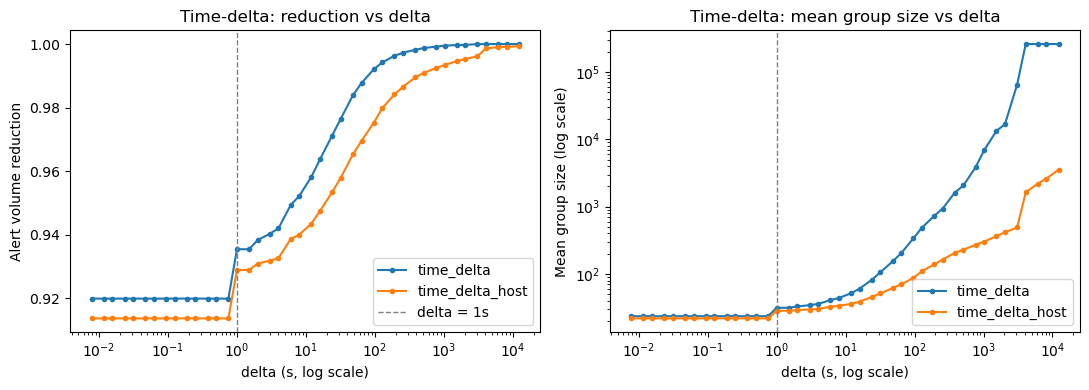

In [31]:
time_delta_df = results_dfs.get("time_delta")
if time_delta_df is None:
    print("[skip] time_delta not loaded -- run time_delta.py first")
else:
    # Per-method diagnostic plot: log-x reduction curve, flags the delta=1s
    # discontinuity described above.
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))

    for method_name, group in time_delta_df.groupby("method"):
        agg = group.groupby("delta", as_index=False)["reduction"].mean().sort_values("delta")
        ax[0].plot(agg["delta"], agg["reduction"], marker=".", label=method_name)

    ax[0].set_xscale("log")
    ax[0].axvline(1.0, color="grey", linestyle="--", linewidth=1, label="delta = 1s")
    ax[0].set_xlabel("delta (s, log scale)")
    ax[0].set_ylabel("Alert volume reduction")
    ax[0].set_title("Time-delta: reduction vs delta")
    ax[0].legend()

    for method_name, group in time_delta_df.groupby("method"):
        agg = group.groupby("delta", as_index=False)["group_size_mean"].mean().sort_values("delta")
        ax[1].plot(agg["delta"], agg["group_size_mean"], marker=".", label=method_name)

    ax[1].set_xscale("log")
    ax[1].set_yscale("log")
    ax[1].axvline(1.0, color="grey", linestyle="--", linewidth=1)
    ax[1].set_xlabel("delta (s, log scale)")
    ax[1].set_ylabel("Mean group size (log scale)")
    ax[1].set_title("Time-delta: mean group size vs delta")
    ax[1].legend()

    plt.tight_layout()
    plt.show()


In [32]:
# Every time-delta setting tested: both variants (global `time_delta`,
# per-host `time_delta_host`), all 42 log-spaced delta values, both
# scenarios. Long by design (168 rows) -- the curves above are the visual
# summary; this is the numeric backing.
if time_delta_df is None:
    print("[skip] time_delta not loaded -- run time_delta.py first")
else:
    time_delta_settings_table = settings_table(
        time_delta_df,
        id_cols=["scenario", "method", "param"],
        sort_cols=["scenario", "method", "delta"],
        title="Time-delta -- every setting tested",
        latex_caption=(
            "Time-delta grouping: every setting tested (global and per-host "
            "variant, all 42 log-spaced $\\delta$ values, both held-out test "
            "scenarios)."
        ),
        latex_label="tab:grouping-time-delta-settings",
        latex_longtable=True,
    )

Time-delta -- every setting tested


reduction  group_size_mean  \
scenario        method          param                                    
fox             time_delta      0.0078         0.9750             39.9   
                                0.0117         0.9750             39.9   
                                0.0156         0.9750             39.9   
                                0.0234         0.9750             39.9   
                                0.0312         0.9750             39.9   
                                0.0469         0.9750             39.9   
                                0.0625         0.9750             39.9   
                                0.0938         0.9750             39.9   
                                0.1250         0.9750             39.9   
                                0.1875         0.9750             39.9   
                                0.2500         0.9750             39.9   
                                0.3750         0.9750             39.9   
                                0.5000         0.9750             39.9   
                                0.7500         0.9750             39.9   
                                1.0000         0.9815             54.1   
                                1.5000         0.9815             54.1   
                                2.0000         0.9824             56.7   
                                3.0000         0.9831             59.3   
                                4.0000         0.9839             62.1   
                                6.0000         0.9858             70.5   
                                8.0000         0.9869             76.3   
                                12.0000        0.9889             89.8   
                                16.0000        0.9906            105.9   
                                24.0000        0.9931            144.7   
                                32.0000        0.9947            188.8   
                                48.0000        0.9963            272.8   
                                64.0000        0.9972            362.3   
                                96.0000        0.9984            606.5   
                                128.0000       0.9989            881.0   
                                192.0000       0.9992           1303.3   
                                256.0000       0.9994           1671.7   
                                384.0000       0.9997           2938.5   
                                512.0000       0.9997           3696.1   
                                768.0000       0.9999           7061.3   
                                1024.0000      0.9999          12786.6   
                                1536.0000      1.0000          24900.2   
                                2048.0000      1.0000          31540.3   
                                3072.0000      1.0000         118276.0   
                                4096.0000      1.0000         473104.0   
                                6144.0000      1.0000         473104.0   
                                8192.0000      1.0000         473104.0   
                                12288.0000     1.0000         473104.0   
                time_delta_host 0.0078         0.9730             37.1   
                                0.0117         0.9730             37.1   
                                0.0156         0.9730             37.1   
                                0.0234         0.9730             37.1   
                                0.0312         0.9730             37.1   
                                0.0469         0.9730             37.1   
                                0.0625         0.9730             37.1   
                                0.0938         0.9730             37.1   
                                0.1250         0.9730             37.1   
                                0.1875         0.9730             37.1   
                                0.2500         0

## 6. CSCAS grouping

CSCAS-style grouping (host + signature split, gap/span-capped sessions) is
**not swept**: it runs at the original authors' own validated production
settings -- `SessionLength = 300 s`, `SessionTimeout = 60 s` (Vaarandi &
Guerra-Manzanares 2024) -- and that single configuration is the one that
feeds the cross-method comparison in section 9.

The rest of this section is a **one-at-a-time robustness check** on those
two parameters (`cscas_grouping_sensitivity.py`, folded in here from what
used to be section 6b): `session_timeout ∈ {30, 60, 120}` with
`session_length` held at 300, then `session_length ∈ {150, 300, 600}` with
`session_timeout` held at 60. The question is whether the published
60 s / 300 s choice still makes sense now that CSCAS-style grouping has
been generalized here from Suricata-only to all three IDS sources -- it is
deliberately **not** a search for a better operating point, so these
sensitivity rows are kept out of `all_results_df` and section 9 (a
sensitivity setting must never compete with the validated config for
CSCAS's slot there). The authors' validated setting is flagged in the
per-setting table at the end of the section.

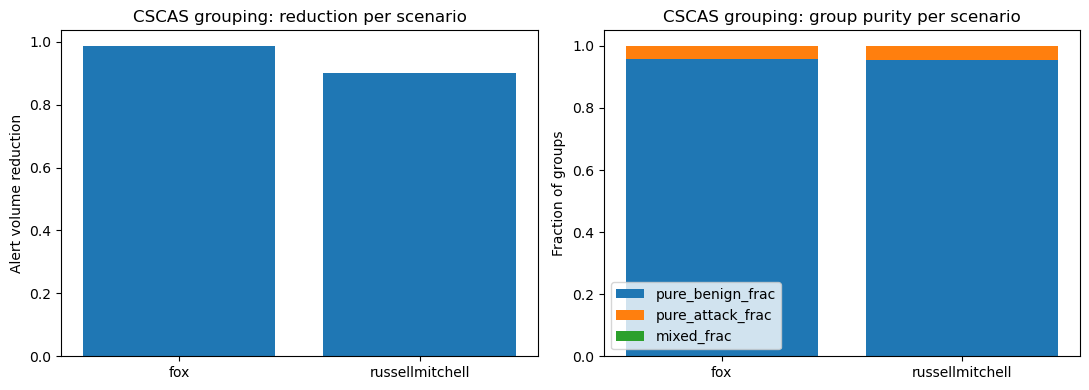

In [33]:
cscas_df = results_dfs.get("cscas_grouping")
if cscas_df is None:
    print("[skip] cscas_grouping not loaded -- run cscas_grouping.py first")
else:
    # Per-method diagnostic plot: reduction and purity per scenario (single config, so bars not curves)
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))

    ax[0].bar(cscas_df["scenario"], cscas_df["reduction"])
    ax[0].set_ylabel("Alert volume reduction")
    ax[0].set_title("CSCAS grouping: reduction per scenario")

    purity_cols = ["pure_benign_frac", "pure_attack_frac", "mixed_frac"]
    bottom = np.zeros(len(cscas_df))
    for col in purity_cols:
        ax[1].bar(cscas_df["scenario"], cscas_df[col], bottom=bottom, label=col)
        bottom += cscas_df[col].values
    ax[1].set_ylabel("Fraction of groups")
    ax[1].set_title("CSCAS grouping: group purity per scenario")
    ax[1].legend()

    plt.tight_layout()
    plt.show()


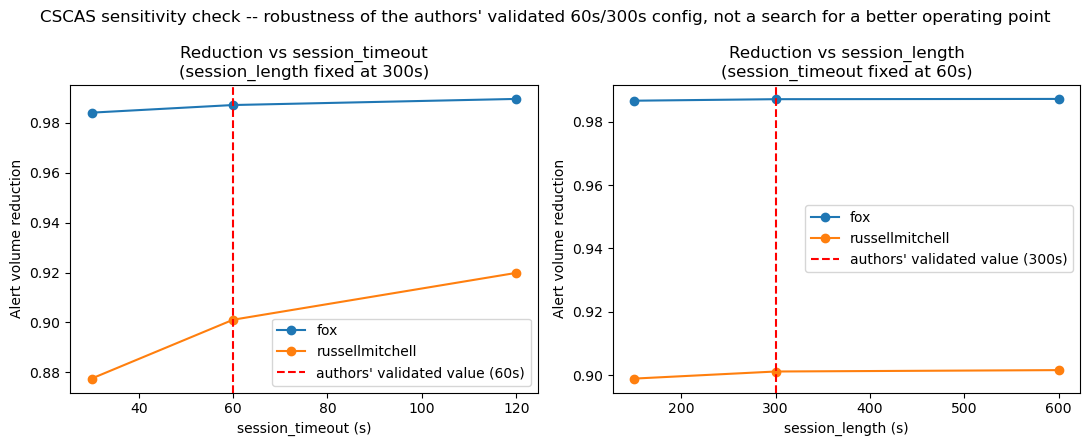

In [34]:
if cscas_sensitivity_df.empty:
    print("[skip] cscas_grouping_sensitivity not loaded -- run cscas_grouping_sensitivity.py first")
else:
    # Sensitivity diagnostic: reduction vs. each parameter, one-at-a-time,
    # with the authors' validated value marked -- a robustness check (does
    # the published config still make sense here), not a search for a
    # better operating point, so the plot deliberately doesn't highlight
    # any other point as "best." Group size / purity for these same
    # settings are in the per-setting table at the end of the section.
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    timeout_df = cscas_sensitivity_df[cscas_sensitivity_df["varied"] == "session_timeout"]
    for scenario in sorted(cscas_sensitivity_df["scenario"].unique()):
        scen_df = timeout_df[timeout_df["scenario"] == scenario].sort_values("varied_value")
        axes[0].plot(scen_df["varied_value"], scen_df["reduction"], marker="o", label=scenario)
    axes[0].axvline(
        CSCAS_SESSION_TIMEOUT_SECONDS, color="red", linestyle="--",
        label=f"authors' validated value ({CSCAS_SESSION_TIMEOUT_SECONDS:g}s)",
    )
    axes[0].set_xlabel("session_timeout (s)")
    axes[0].set_ylabel("Alert volume reduction")
    axes[0].set_title(f"Reduction vs session_timeout\n(session_length fixed at {CSCAS_SESSION_LENGTH_SECONDS:g}s)")
    axes[0].legend()

    length_df = cscas_sensitivity_df[cscas_sensitivity_df["varied"] == "session_length"]
    for scenario in sorted(cscas_sensitivity_df["scenario"].unique()):
        scen_df = length_df[length_df["scenario"] == scenario].sort_values("varied_value")
        axes[1].plot(scen_df["varied_value"], scen_df["reduction"], marker="o", label=scenario)
    axes[1].axvline(
        CSCAS_SESSION_LENGTH_SECONDS, color="red", linestyle="--",
        label=f"authors' validated value ({CSCAS_SESSION_LENGTH_SECONDS:g}s)",
    )
    axes[1].set_xlabel("session_length (s)")
    axes[1].set_ylabel("Alert volume reduction")
    axes[1].set_title(f"Reduction vs session_length\n(session_timeout fixed at {CSCAS_SESSION_TIMEOUT_SECONDS:g}s)")
    axes[1].legend()

    fig.suptitle("CSCAS sensitivity check -- robustness of the authors' validated 60s/300s config, not a search for a better operating point")
    plt.tight_layout()
    plt.show()

In [35]:
# Every CSCAS setting tried: the 5 distinct (session_length,
# session_timeout) points of the one-at-a-time check -- the shared 300/60
# primary, which both grids pass through, is de-duplicated -- each
# scenario, with `authors_validated` flagging the original authors' own
# production config. cscas_grouping_sensitivity.json recomputes the 300/60
# point itself so it carries every setting; cscas_grouping.json is the
# fallback when only the primary script has been run.
_cscas_primary = results_dfs.get("cscas_grouping")
if not cscas_sensitivity_df.empty:
    _cscas_src = cscas_sensitivity_df
elif _cscas_primary is not None:
    _cscas_src = _cscas_primary.assign(
        session_length=CSCAS_SESSION_LENGTH_SECONDS,
        session_timeout=CSCAS_SESSION_TIMEOUT_SECONDS,
    )
else:
    _cscas_src = None

if _cscas_src is None:
    print("[skip] no CSCAS results -- run cscas_grouping.py (and cscas_grouping_sensitivity.py) first")
else:
    cscas_settings_table = settings_table(
        _cscas_src.assign(
            setting=lambda d: (
                "length=" + d["session_length"].map("{:.0f}s".format)
                + ", timeout=" + d["session_timeout"].map("{:.0f}s".format)
            ),
            authors_validated=lambda d: (
                d["session_length"].eq(CSCAS_SESSION_LENGTH_SECONDS)
                & d["session_timeout"].eq(CSCAS_SESSION_TIMEOUT_SECONDS)
            ),
        ).drop_duplicates(subset=["scenario", "session_length", "session_timeout"]),
        id_cols=["scenario", "setting", "authors_validated"],
        sort_cols=["scenario", "session_length", "session_timeout"],
        title="CSCAS -- every setting tested (authors' validated config flagged)",
        latex_caption=(
            "CSCAS grouping: the one-at-a-time sensitivity check around the "
            "authors' validated 300\\,s / 60\\,s configuration "
            "(\\emph{Authors' cfg} flags that row), both held-out test scenarios."
        ),
        latex_label="tab:grouping-cscas-settings",
    )

CSCAS -- every setting tested (authors' validated config flagged)


reduction  \
scenario        setting                   authors_validated              
fox             length=150s, timeout=60s  False                 0.9866   
                length=300s, timeout=30s  False                 0.9841   
                length=300s, timeout=60s  True                  0.9871   
                length=300s, timeout=120s False                 0.9896   
                length=600s, timeout=60s  False                 0.9872   
russellmitchell length=150s, timeout=60s  False                 0.8989   
                length=300s, timeout=30s  False                 0.8775   
                length=300s, timeout=60s  True                  0.9011   
                length=300s, timeout=120s False                 0.9199   
                length=600s, timeout=60s  False                 0.9015   

                                                             group_size_mean  \
scenario        setting                   authors_validated                    
fox             length=150s, timeout=60s  False                         74.9   
                length=300s, timeout=30s  False                         62.8   
                length=300s, timeout=60s  True                          77.6   
                length=300s, timeout=120s False                         95.9   
                length=600s, timeout=60s  False                         78.2   
russellmitchell length=150s, timeout=60s  False                          9.9   
                length=300s, timeout=30s  False                          8.2   
                length=300s, timeout=60s  True                          10.1   
                length=300s, timeout=120s False                         12.5   
                length=600s, timeout=60s  False                         10.2   

                                                             group_size_median  \
scenario        setting                   authors_validated                      
fox             length=150s, timeout=60s  False                            4.0   
                length=300s, timeout=30s  False                            3.0   
                length=300s, timeout=60s  True                             4.0   
                length=300s, timeout=120s False                            5.0   
                length=600s, timeout=60s  False                            4.0   
russellmitchell length=150s, timeout=60s  False                            4.0   
                length=300s, timeout=30s  False                            3.0   
                length=300s, timeout=60s  True                             4.0   
                length=300s, timeout=120s False                            4.0   
                length=600s, timeout=60s  False                            4.0   

                                                             group_size_max  \
scenario        setting                   authors_validated                   
fox             length=150s, timeout=60s  False                       49662   
                length=300s, timeout=30s  False                       98788   
                length=300s, timeout=60s  True                        98788   
                length=300s, timeout=120s False                       98788   
                length=600s, timeout=60s  False                      195756   
russellmitchell length=150s, timeout=60s  False                        7068   
                length=300s, timeout=30s  False                        7068   
                length=300s, timeout=60s  True                         7068   
                length=300s, timeout=120s False                        7068   
                length=600s, timeout=60s  False                        7068   

                                                             pure_benign_frac  \
scenario        setting                   authors_validated                     
fox             length=150s, timeout=60s  False                        0.9513   
                length=300s, timeo

## 7. AlertBERT

Delta and theta swept separately, matching the AlertBERT paper's own
asymmetric design -- see `alertbert_sweep.py`'s module docstring for the full
grid rationale, checkpoint compatibility, and GPU/conda-env requirements.
Its rows also feed directly into section 9's cross-method comparison.


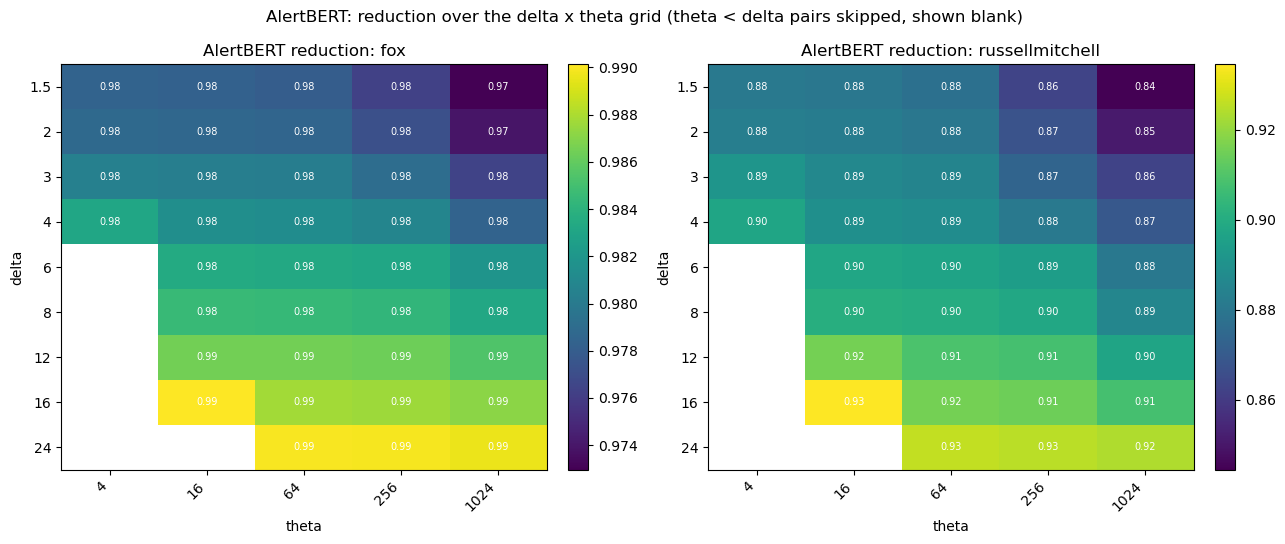

In [36]:
alertbert_df = results_dfs.get("alertbert")
if alertbert_df is None:
    print("[skip] alertbert not loaded -- run alertbert_sweep.py first")
else:
    # Diagnostic plot: reduction over the full delta x theta grid, one
    # heatmap per scenario -- a genuine 2-parameter sweep, so a heatmap
    # shows it more directly than a line plot would (contrast with the
    # CSCAS sensitivity sweep in 6b, which is deliberately one-at-a-time,
    # not a real 2D grid, so line plots were the right choice there instead).
    scenarios = sorted(alertbert_df["scenario"].unique())
    deltas = sorted(alertbert_df["delta"].unique())
    thetas = sorted(alertbert_df["theta"].unique())

    fig, axes = plt.subplots(1, len(scenarios), figsize=(6.5 * len(scenarios), 5.5), squeeze=False)
    for ax, scenario in zip(axes[0], scenarios):
        scen_df = alertbert_df[alertbert_df["scenario"] == scenario]
        pivot = scen_df.pivot(index="delta", columns="theta", values="reduction")
        pivot = pivot.reindex(index=deltas, columns=thetas)
        im = ax.imshow(pivot.values, cmap="viridis", aspect="auto")
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                val = pivot.values[i, j]
                if not np.isnan(val):
                    ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7, color="white")
        ax.set_xticks(range(len(thetas)))
        ax.set_xticklabels([f"{t:g}" for t in thetas], rotation=45, ha="right")
        ax.set_yticks(range(len(deltas)))
        ax.set_yticklabels([f"{d:g}" for d in deltas])
        ax.set_xlabel("theta")
        ax.set_ylabel("delta")
        ax.set_title(f"AlertBERT reduction: {scenario}")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle("AlertBERT: reduction over the delta x theta grid (theta < delta pairs skipped, shown blank)")
    plt.tight_layout()
    plt.show()


In [37]:
# Every AlertBERT setting tested: the (delta, theta) pairs with
# theta >= delta (theta < delta is skipped upstream), both scenarios.
if alertbert_df is None:
    print("[skip] alertbert not loaded -- run alertbert_sweep.py first")
else:
    alertbert_settings_table = settings_table(
        alertbert_df,
        id_cols=["scenario", "delta", "theta"],
        sort_cols=["scenario", "delta", "theta"],
        title="AlertBERT -- every setting tested",
        latex_caption=(
            "AlertBERT grouping: every $(\\delta, \\theta)$ pair tested "
            "($\\theta \\geq \\delta$; smaller pairs skipped upstream), both "
            "held-out test scenarios."
        ),
        latex_label="tab:grouping-alertbert-settings",
        latex_longtable=True,
    )

AlertBERT -- every setting tested


reduction  group_size_mean  group_size_median  \
scenario        delta theta                                                   
fox             1.5   4.0        0.9784             46.4                3.0   
                      16.0       0.9783             46.1                3.0   
                      64.0       0.9780             45.5                3.0   
                      256.0      0.9763             42.2                3.0   
                      1024.0     0.9730             37.0                3.0   
                2.0   4.0        0.9789             47.3                3.0   
                      16.0       0.9787             47.0                3.0   
                      64.0       0.9786             46.7                3.0   
                      256.0      0.9772             43.8                3.0   
                      1024.0     0.9739             38.3                3.0   
                3.0   4.0        0.9804             51.1                3.0   
                      16.0       0.9803             50.8                3.0   
                      64.0       0.9802             50.6                3.0   
                      256.0      0.9791             47.9                3.0   
                      1024.0     0.9764             42.4                3.0   
                4.0   4.0        0.9831             59.3                3.0   
                      16.0       0.9815             53.9                3.0   
                      64.0       0.9813             53.5                3.0   
                      256.0      0.9808             52.1                3.0   
                      1024.0     0.9784             46.4                3.0   
                6.0   16.0       0.9834             60.4                3.0   
                      64.0       0.9833             59.9                3.0   
                      256.0      0.9831             59.2                3.0   
                      1024.0     0.9818             55.1                3.0   
                8.0   16.0       0.9846             64.7                3.0   
                      64.0       0.9845             64.3                3.0   
                      256.0      0.9843             63.6                3.0   
                      1024.0     0.9832             59.6                3.0   
                12.0  16.0       0.9865             74.1                3.0   
                      64.0       0.9865             74.0                3.0   
                      256.0      0.9863             73.1                3.0   
                      1024.0     0.9854             68.6                3.0   
                16.0  16.0       0.9901            101.4                6.0   
                      64.0       0.9878             81.8                6.0   
                      256.0      0.9876             80.7                6.0   
                      1024.0     0.9871             77.7                6.0   
                24.0  64.0       0.9900             99.9                6.0   
                      256.0      0.9899             99.0                6.0   
                      1024.0     0.9896             96.3                6.0   
russellmitchell 1.5   4.0        0.8810              8.4                3.0   
                      16.0       0.8800              8.3                3.0   
                      64.0       0.8778              8.2                3.0   
                      256.0      0.8631              7.3                3.0   
                      1024.0     0.8445              6.4                3.0   
                2.0   4.0        0.8831              8.6                3.0   
                      16.0       0.8821              8.5                3.0   
                      64.0       0.8803              8.4                3.0   
                      256.0      0.8674              7.5                3.0   
                      1024.0     0.8509              6.7                3.0   
 

## 8. DeepCASE

Two-tier sweep (context length x DBSCAN eps) -- see `deepcase_sweep.py`'s module
docstring for the full sweep design, outlier convention, and runtime notes.


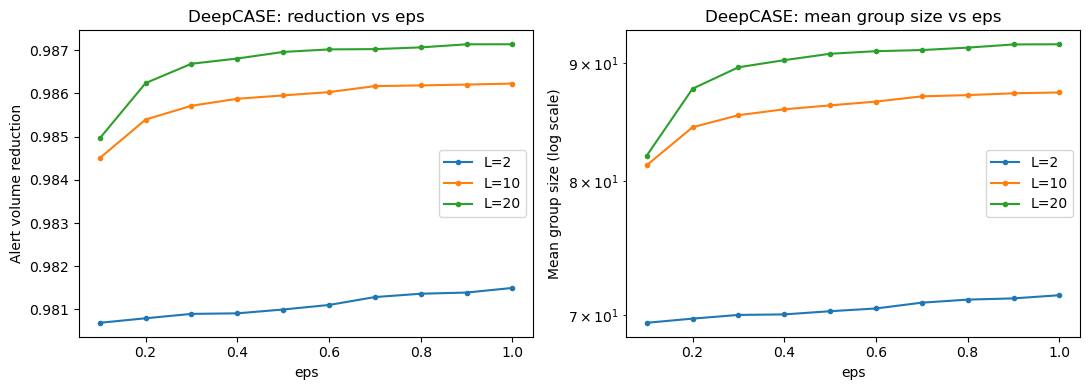

In [38]:
deepcase_df = results_dfs.get("deepcase")
if deepcase_df is None:
    print("[skip] deepcase not loaded -- run deepcase_sweep.py first")
else:
    # Per-method diagnostic plot: reduction and mean group size vs eps, one
    # line per context length L.
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))

    for L, group in deepcase_df.groupby("context_length"):
        agg = group.groupby("eps", as_index=False)["reduction"].mean().sort_values("eps")
        ax[0].plot(agg["eps"], agg["reduction"], marker=".", label=f"L={L}")

    ax[0].set_xlabel("eps")
    ax[0].set_ylabel("Alert volume reduction")
    ax[0].set_title("DeepCASE: reduction vs eps")
    ax[0].legend()

    for L, group in deepcase_df.groupby("context_length"):
        agg = group.groupby("eps", as_index=False)["group_size_mean"].mean().sort_values("eps")
        ax[1].plot(agg["eps"], agg["group_size_mean"], marker=".", label=f"L={L}")

    ax[1].set_yscale("log")
    ax[1].set_xlabel("eps")
    ax[1].set_ylabel("Mean group size (log scale)")
    ax[1].set_title("DeepCASE: mean group size vs eps")
    ax[1].legend()

    plt.tight_layout()
    plt.show()


In [39]:
# Every DeepCASE setting tested: the context_length x eps grid (3 x 10 in
# a full GROUPING_RUN_FULL_DEEPCASE_SWEEP=1 run), both scenarios.
if deepcase_df is None:
    print("[skip] deepcase not loaded -- run deepcase_sweep.py first")
else:
    deepcase_settings_table = settings_table(
        deepcase_df,
        id_cols=["scenario", "context_length", "eps"],
        sort_cols=["scenario", "context_length", "eps"],
        title="DeepCASE -- every setting tested",
        latex_caption=(
            "DeepCASE grouping: the context-length $L$ $\\times$ "
            "DBSCAN-$\\varepsilon$ grid, both held-out test scenarios."
        ),
        latex_label="tab:grouping-deepcase-settings",
        latex_longtable=True,
    )

DeepCASE -- every setting tested


reduction  group_size_mean  \
scenario        context_length eps                               
fox             2              0.1     0.9904            104.5   
                               0.2     0.9905            104.8   
                               0.3     0.9905            105.1   
                               0.4     0.9905            105.2   
                               0.5     0.9905            105.4   
                               0.6     0.9905            105.6   
                               0.7     0.9906            106.0   
                               0.8     0.9906            106.2   
                               0.9     0.9906            106.4   
                               1.0     0.9906            106.6   
                10             0.1     0.9915            118.1   
                               0.2     0.9917            121.1   
                               0.3     0.9918            121.7   
                               0.4     0.9918            122.0   
                               0.5     0.9918            122.3   
                               0.6     0.9918            122.6   
                               0.7     0.9919            122.9   
                               0.8     0.9919            123.0   
                               0.9     0.9919            123.3   
                               1.0     0.9919            123.3   
                20             0.1     0.9915            117.7   
                               0.2     0.9919            124.0   
                               0.3     0.9920            125.6   
                               0.4     0.9921            126.3   
                               0.5     0.9921            126.6   
                               0.6     0.9921            126.8   
                               0.7     0.9921            127.0   
                               0.8     0.9921            127.2   
                               0.9     0.9921            127.4   
                               1.0     0.9922            127.4   
russellmitchell 2              0.1     0.9710             34.4   
                               0.2     0.9711             34.6   
                               0.3     0.9713             34.8   
                               0.4     0.9713             34.9   
                               0.5     0.9715             35.1   
                               0.6     0.9717             35.3   
                               0.7     0.9720             35.7   
                               0.8     0.9721             35.9   
                               0.9     0.9722             35.9   
                               1.0     0.9724             36.2   
                10             0.1     0.9775             44.4   
                               0.2     0.9791             47.7   
                               0.3     0.9796             49.1   
                               0.4     0.9800             49.9   
                               0.5     0.9801             50.2   
                               0.6     0.9802             50.5   
                               0.7     0.9805             51.2   
                               0.8     0.9805             51.3   
                               0.9     0.9805             51.3   
                               1.0     0.9806             51.5   
                20             0.1     0.9784             46.3   
                               0.2     0.9805             51.4   
                               0.3     0.9813             53.6   
                               0.4     0.9815             54.2   
                               0.5     0.9818             55.0   
                               0.6     0.9819             55.3   
                               0.7     0.9819             55.3   
                               0.8     0.9820             55.5   
                               0.9     0.9821             56.0   
          

### 8b. DeepCASE manual-review queue

Each outlier alert's `reason` (`"deepcase_low_confidence"` vs
`"deepcase_dbscan_noise"`) feeds `build_manual_review_records` (inside
`deepcase_sweep.py`), which turns the rejected alerts at each (scenario,
context_length)'s default eps into the actual queue those alerts would be
routed to for analyst review, mirroring DeepCASE's own semi-automatic mode
rather than just a conceptual description.


In [40]:
manual_review_df.to_csv("grouping_manual_review_queue.csv", index=False)
print(f"Manual review queue: {len(manual_review_df)} alerts")
if not manual_review_df.empty:
    print(manual_review_df["reason"].value_counts())


Manual review queue: 104428 alerts
reason
deepcase_low_confidence    102618
deepcase_dbscan_noise        1810
Name: count, dtype: int64


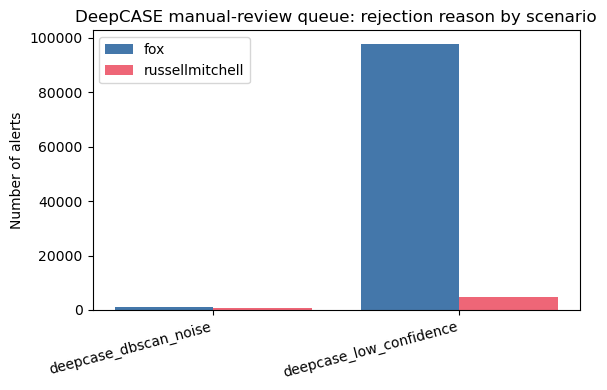

In [41]:
if manual_review_df.empty:
    print("[skip] no manual review rows loaded -- run deepcase_sweep.py first")
else:
    fig, ax = plt.subplots(figsize=(6, 4))
    reasons = sorted(manual_review_df["reason"].unique())
    scenarios = sorted(manual_review_df["scenario"].unique())
    x = np.arange(len(reasons))
    width = 0.8 / len(scenarios)

    for i, scenario in enumerate(scenarios):
        counts = (
            manual_review_df[manual_review_df["scenario"] == scenario]["reason"]
            .value_counts()
            .reindex(reasons, fill_value=0)
        )
        ax.bar(
            x + (i - (len(scenarios) - 1) / 2) * width, counts.values, width=width,
            label=scenario, color=SCENARIO_COLORS.get(scenario),
        )

    ax.set_xticks(x)
    ax.set_xticklabels(reasons, rotation=15, ha="right")
    ax.set_ylabel("Number of alerts")
    ax.set_title("DeepCASE manual-review queue: rejection reason by scenario")
    ax.legend()
    plt.tight_layout()
    plt.show()


## 9. Combined results and final comparison plots

Everything loaded above, combined into one DataFrame.


In [42]:
all_results_df.to_csv("grouping_comparison_results.csv", index=False)

if all_results_df.empty:
    print("[skip] no results loaded -- run the baseline scripts first")
    summary_table = None
else:
    # Structural finding, not a trivial case: DeepCASE is the only method in
    # this comparison with a rejection/deferral path, so it should be the
    # only method with a nonzero ungroupable_fraction -- worth asserting, not
    # just omitting as an obvious zero.
    non_deepcase_ungroupable = all_results_df.loc[
        all_results_df["method"] != "deepcase", "ungroupable_fraction"
    ]
    assert (non_deepcase_ungroupable == 0.0).all(), (
        "Expected ungroupable_fraction == 0.0 for every non-DeepCASE method "
        "(none of them have a rejection step)"
    )
    print(
        "Confirmed: ungroupable_fraction is 0.0 for every non-DeepCASE method "
        "-- DeepCASE is the only method here with a rejection/deferral mode."
    )

    summary_table = all_results_df.groupby("method")[[
        "reduction", "coverage", "ungroupable_fraction", "group_size_mean", "n_groups",
        "pure_benign_frac", "pure_attack_frac", "mixed_frac",
        "host_purity", "signature_diversity_mean", "temporal_span_mean",
        "minority_label_exposure", "train_time_seconds", "inference_time_seconds",
    ]].mean()

summary_table


Confirmed: ungroupable_fraction is 0.0 for every non-DeepCASE method -- DeepCASE is the only method here with a rejection/deferral mode.


,reduction,coverage,ungroupable_fraction,group_size_mean,n_groups,pure_benign_frac,pure_attack_frac,mixed_frac,host_purity,signature_diversity_mean,temporal_span_mean,minority_label_exposure,train_time_seconds,inference_time_seconds
method,,,,,,,,,,,,,,
alertbert,0.936865,1.000000,0.000000,35.059433,6669.064103,0.934032,0.065865,0.000104,0.873958,1.416130,1.590782,0.234241,NaN,15.790034
cscas_grouping,0.944114,1.000000,0.000000,43.879518,5298.500000,0.955665,0.043809,0.000526,1.000000,1.000000,20.269532,0.409420,NaN,0.542742
deepcase,0.984541,0.947268,0.052732,82.014233,2530.700000,0.542713,0.445367,0.011921,0.979115,1.004524,5346.191414,0.015594,175.425784,NaN
fixed_window,0.942503,1.000000,0.000000,40.906919,6204.583333,0.956497,0.043382,0.000121,0.811010,1.570445,4.215183,0.073810,NaN,0.186453
fixed_window_host,0.932446,1.000000,0.000000,31.081255,7360.166667,0.952113,0.047864,0.000023,1.000000,1.463302,2.188384,0.041667,NaN,0.213730
time_delta,0.959199,1.000000,0.000000,27390.133171,4452.940476,0.856638,0.036840,0.106522,0.611501,10.154303,40474.356323,0.128821,NaN,0.368702
time_delta_host,0.950781,1.000000,0.000000,324.320653,5393.357143,0.937412,0.049216,0.013371,1.000000,2.003711,2756.918284,0.151148,NaN,0.402716


In [ ]:
# LaTeX -- section 9 cross-method summary. Needs \usepackage{booktabs} and
# \usepackage{graphicx} (for \resizebox). Metrics stay as columns, matching
# the DataFrame above; transpose in LaTeX if a tall layout reads better.
if summary_table is not None and not summary_table.empty:
    print(to_latex_table(
        summary_table.rename_axis("method"),
        caption=(
            "Cross-method comparison: each method's mean over all swept "
            "settings and both held-out test scenarios "
            "(\\texttt{fox}, \\texttt{russellmitchell})."
        ),
        label="tab:grouping-summary",
        resizebox=True,
    ))

In [43]:
if all_results_df.empty:
    best_settings = pd.DataFrame()
else:
    # Jointly-best setting per method: pick ONE param per method that
    # maximizes MEAN reduction across both scenarios, then use that same
    # param's row in each scenario (still one row per method x scenario,
    # so the plots below can show both scenarios side by side).
    #
    # Deliberately NOT two independent per-scenario argmaxes (the
    # previous approach): a deployed method runs at a single
    # configuration, so averaging two independently-chosen "best"
    # scenario results would silently report the combined performance of
    # two different, never-co-deployed operating points as if it were
    # one. This also makes Gate 3's cross-scenario gap (section 10.3)
    # meaningful: the gap is now guaranteed to compare the SAME param's
    # reduction across scenarios, rather than two different params that
    # each happen to be near their own scenario's ceiling.
    param_mean_reduction = (
        all_results_df.groupby(["method", "param"], as_index=False)["reduction"].mean()
    )
    best_param_per_method = (
        param_mean_reduction.sort_values("reduction", ascending=False)
        .groupby("method", as_index=False)
        .first()[["method", "param"]]
    )
    best_settings = all_results_df.merge(best_param_per_method, on=["method", "param"])

    # Sanity check: does the jointly-optimal param happen to also be each
    # scenario's own independent optimum? Not required for correctness --
    # the joint param is deliberately chosen for the pair, not for either
    # scenario alone -- but a mismatch would mean this method's scenarios
    # genuinely pull toward different operating points, which is worth
    # surfacing rather than silently averaging over.
    independent_best = (
        all_results_df.sort_values("reduction", ascending=False)
        .groupby(["method", "scenario"], as_index=False)
        .first()[["method", "scenario", "param"]]
    )
    joint_param_by_method = best_param_per_method.set_index("method")["param"]
    independent_best["diverges_from_joint"] = independent_best.apply(
        lambda r: r["param"] != joint_param_by_method.get(r["method"]), axis=1
    )
    diverging = independent_best[independent_best["diverges_from_joint"]]
    if diverging.empty:
        print(
            "Confirmed: the joint (mean-maximizing) param matches each "
            "scenario's own independent best-reduction param, for every "
            "method -- no method's scenarios pull toward different "
            "operating points."
        )
    else:
        print(
            "NOTE: for the (method, scenario) pairs below, the scenario's "
            "own independent best param differs from the joint param used "
            "in best_settings -- that method's reported reduction on this "
            "scenario is therefore NOT its own per-scenario ceiling:\n"
            + diverging.drop(columns="diverges_from_joint").to_string(index=False)
        )

best_settings.head()


NOTE: for the (method, scenario) pairs below, the scenario's own independent best param differs from the joint param used in best_settings -- that method's reported reduction on this scenario is therefore NOT its own per-scenario ceiling:
    method        scenario        param
  deepcase russellmitchell L=20_eps=0.9
time_delta             fox    4096.0000
time_delta russellmitchell    4096.0000


,method,param,n_raw_alerts,reduction,coverage,ungroupable_fraction,group_size_mean,group_size_median,group_size_max,n_groups,...,signature_diversity_max,temporal_span_mean,temporal_span_median,temporal_span_max,minority_label_exposure,scenario,delta,theta,context_length,eps
0,fixed_window,60,473104,0.992435,1.0,0.0,132.188880,9.0,22117,3579,...,19,19.684269,17.0,59.0,0.142857,fox,NaN,NaN,NaN,NaN
1,fixed_window_host,60,473104,0.987197,1.0,0.0,78.108635,6.0,22117,6057,...,14,9.764735,0.0,59.0,0.000000,fox,NaN,NaN,NaN,NaN
2,fixed_window,60,45544,0.948753,1.0,0.0,19.513282,8.0,5961,2334,...,21,16.395030,10.0,59.0,0.266667,russellmitchell,NaN,NaN,NaN,NaN
3,fixed_window_host,60,45544,0.920758,1.0,0.0,12.619562,6.0,5953,3609,...,14,8.477972,0.0,59.0,0.500000,russellmitchell,NaN,NaN,NaN,NaN
4,time_delta,12288.0000,473104,0.999998,1.0,0.0,473104.000000,473104.0,473104,1,...,77,431735.000000,431735.0,431735.0,0.108752,fox,12288.0,NaN,NaN,NaN


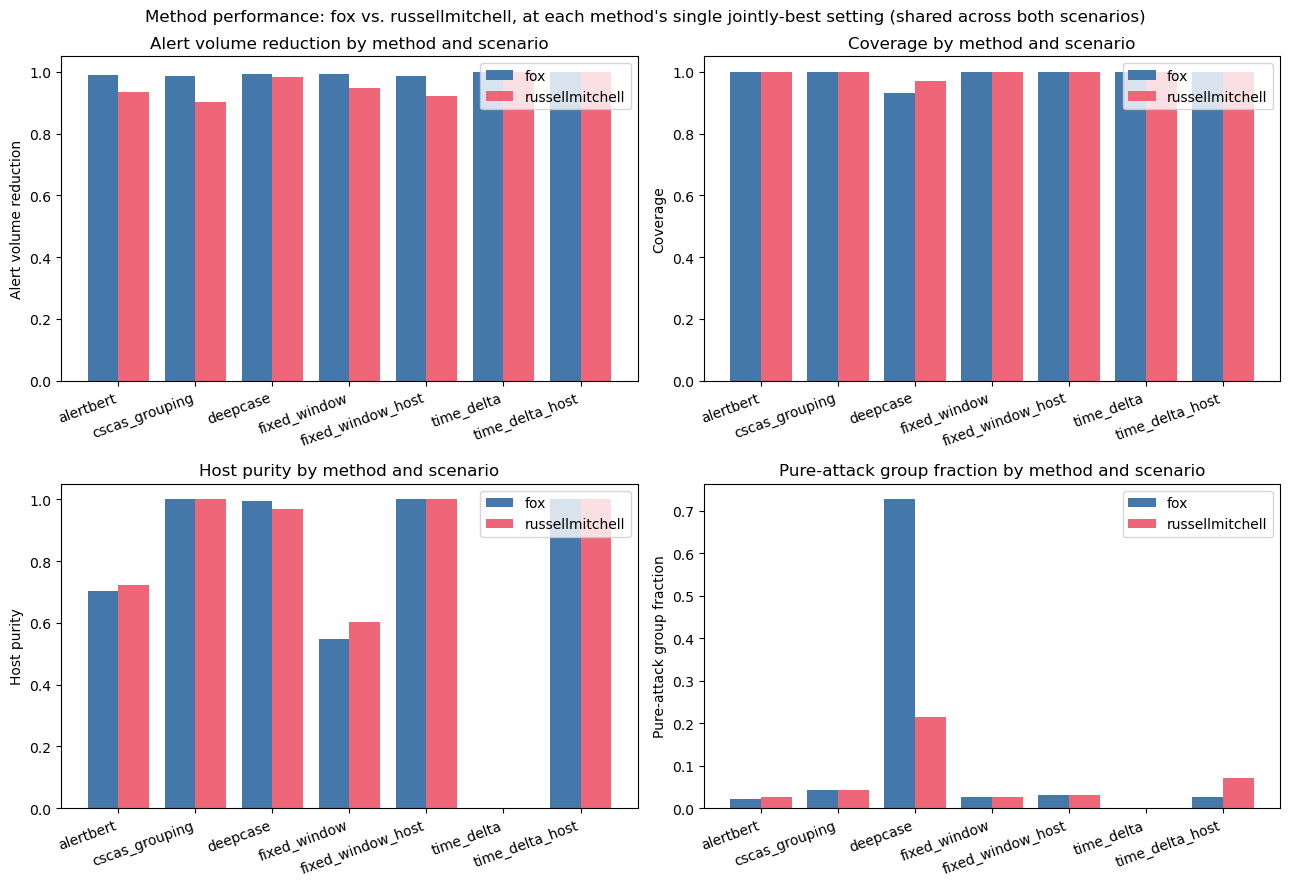

In [44]:
if best_settings.empty:
    print("[skip] no results loaded -- run the baseline scripts first")
else:
    # Headline comparison: does each method perform consistently across
    # both test scenarios, or does it diverge? One panel per metric, each a
    # grouped bar chart (method on x-axis, one bar per scenario) built from
    # each method's single jointly-best setting (chosen in section 9 to
    # maximize mean reduction across both scenarios), evaluated on each
    # scenario in turn -- not two independently-tuned settings.
    metrics = [
        ("reduction", "Alert volume reduction"),
        ("coverage", "Coverage"),
        ("host_purity", "Host purity"),
        ("pure_attack_frac", "Pure-attack group fraction"),
    ]
    methods = sorted(best_settings["method"].unique())
    scenarios = sorted(best_settings["scenario"].unique())
    x = np.arange(len(methods))
    width = 0.8 / len(scenarios)

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    for ax, (col, title) in zip(axes.flat, metrics):
        for i, scenario in enumerate(scenarios):
            scen_df = best_settings[best_settings["scenario"] == scenario].set_index("method")
            values = [scen_df[col].get(m, 0.0) for m in methods]
            ax.bar(
                x + (i - (len(scenarios) - 1) / 2) * width, values, width=width,
                label=scenario, color=SCENARIO_COLORS.get(scenario),
            )
        ax.set_xticks(x)
        ax.set_xticklabels(methods, rotation=20, ha="right")
        ax.set_ylabel(title)
        ax.set_title(f"{title} by method and scenario")
        ax.legend()

    fig.suptitle("Method performance: fox vs. russellmitchell, at each method's single jointly-best setting (shared across both scenarios)")
    plt.tight_layout()
    plt.show()


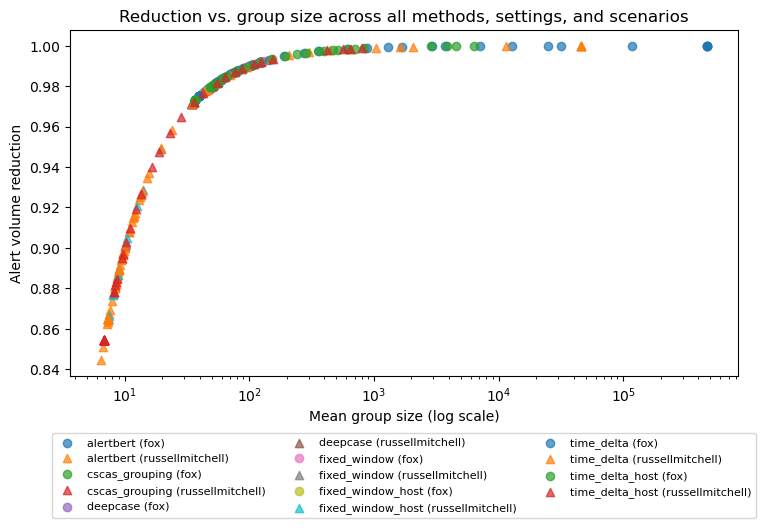

In [45]:
if all_results_df.empty:
    print("[skip] no results loaded -- run the baseline scripts first")
else:
    # Final plot 1: reduction vs mean group size, all methods overlaid,
    # split by scenario (marker shape) so a method that performs very
    # differently on fox vs russellmitchell doesn't get silently averaged
    # away. This is the key tradeoff plot -- high reduction from one giant
    # group is not the same achievement as high reduction from many
    # well-formed groups.
    fig, ax = plt.subplots(figsize=(8, 5.5))

    for (method_name, scenario), group in all_results_df.groupby(["method", "scenario"]):
        agg = group.groupby("param", as_index=False)[["reduction", "group_size_mean"]].mean()
        ax.scatter(
            agg["group_size_mean"], agg["reduction"],
            label=f"{method_name} ({scenario})",
            marker=SCENARIO_MARKERS.get(scenario, "o"),
            alpha=0.7,
        )

    ax.set_xscale("log")
    ax.set_xlabel("Mean group size (log scale)")
    ax.set_ylabel("Alert volume reduction")
    ax.set_title("Reduction vs. group size across all methods, settings, and scenarios")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=8)
    plt.tight_layout()
    plt.show()


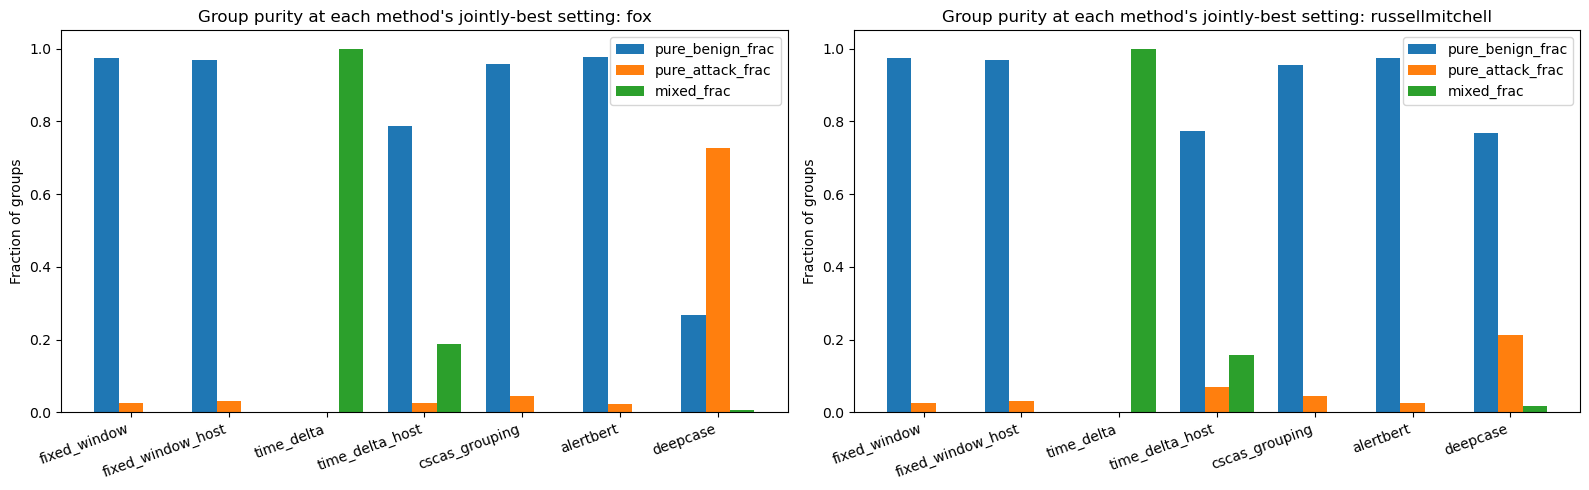

In [46]:
if best_settings.empty:
    print("[skip] no results loaded -- run the baseline scripts first")
else:
    # Final plot 2: purity comparison at each method's jointly-best
    # setting (section 9), faceted by scenario (not pooled) -- one
    # subplot per scenario so no method's bar silently reflects a
    # different scenario than another method's.
    scenarios = sorted(best_settings["scenario"].unique())
    fig, axes = plt.subplots(1, len(scenarios), figsize=(8 * len(scenarios), 5), squeeze=False)

    for ax, scenario in zip(axes[0], scenarios):
        scen_settings = best_settings[best_settings["scenario"] == scenario]
        x = np.arange(len(scen_settings))
        width = 0.25

        for i, col in enumerate(["pure_benign_frac", "pure_attack_frac", "mixed_frac"]):
            ax.bar(x + i * width, scen_settings[col], width=width, label=col)

        ax.set_xticks(x + width)
        ax.set_xticklabels(scen_settings["method"], rotation=20, ha="right")
        ax.set_ylabel("Fraction of groups")
        ax.set_title(f"Group purity at each method's jointly-best setting: {scenario}")
        ax.legend()

    plt.tight_layout()
    plt.show()


/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_68805/3598010401.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=labels, showfliers=True)
/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_68805/3598010401.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=labels, showfliers=True)


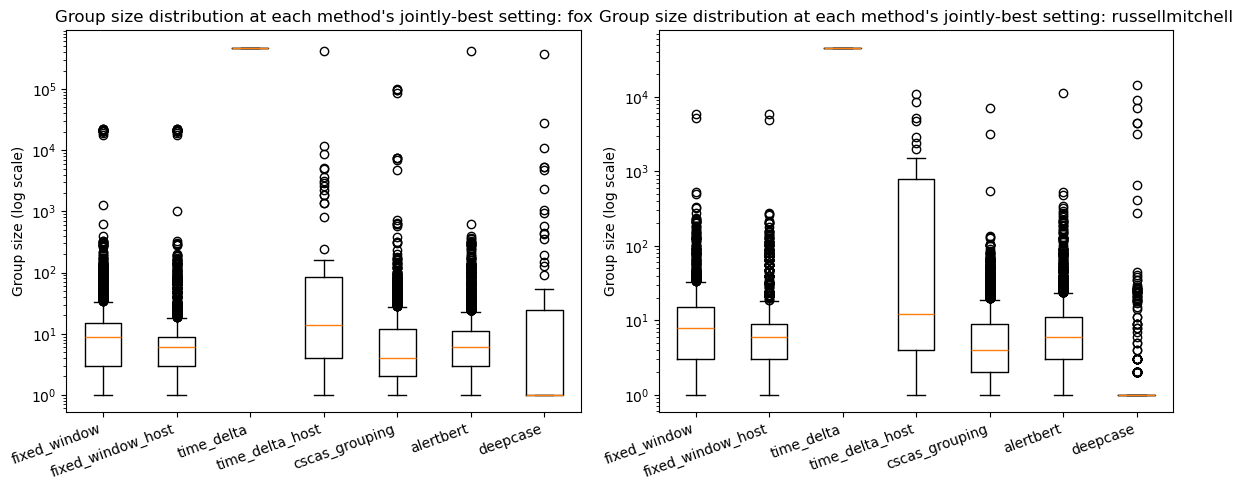

In [47]:
if best_settings.empty:
    print("[skip] no results loaded -- run the baseline scripts first")
else:
    # Final plot 3: group size distributions (log-y boxplot) at each
    # method's jointly-best setting (section 9), faceted by scenario --
    # surfaces the runaway-group pathology (long streams of dense,
    # repetitive alerts collapsing into a single giant group) that flat
    # mean/median stats can hide. Needs the raw per-setting arrays from
    # *_sizes.npz, not just the mean/median/max already in all_results_df.
    scenarios = sorted(best_settings["scenario"].unique())
    fig, axes = plt.subplots(1, len(scenarios), figsize=(6 * len(scenarios), 5), squeeze=False)

    any_data = False
    for ax, scenario in zip(axes[0], scenarios):
        scen_settings = best_settings[best_settings["scenario"] == scenario]
        box_data = []
        labels = []
        for _, row in scen_settings.iterrows():
            key = (row["method"], row["param"], row["scenario"])
            if key in size_arrays:
                box_data.append(size_arrays[key])
                labels.append(row["method"])

        if box_data:
            any_data = True
            ax.boxplot(box_data, labels=labels, showfliers=True)
            ax.set_yscale("log")
            ax.set_ylabel("Group size (log scale)")
            ax.set_title(f"Group size distribution at each method's jointly-best setting: {scenario}")
            ax.set_xticklabels(labels, rotation=20, ha="right")
        else:
            ax.set_title(f"{scenario}: no group-size arrays loaded")

    plt.tight_layout()
    if any_data:
        plt.show()
    else:
        print("[skip] no group-size arrays loaded for any best setting")


## 10. Integration screening

The comparison above (section 9) treats all five methods symmetrically. This
section reframes the same underlying results around a different question:
**which of these methods are viable drop-in grouping components for the
system being designed, not just which one scores highest overall.**

For each requirement below, a leaderboard ranks *all five methods* against a
threshold line -- nothing is dropped yet, so every method's full profile is
visible before any elimination happens. Section 11 then combines all
requirements into a single scorecard and applies them together to see which
methods actually survive.


In [48]:
# --- Placeholder thresholds -------------------------------------------
# TODO: replace with the actual requirements of the target system before
# the thesis write-up. These are illustrative placeholders only -- they are
# NOT tuned to make any particular method look good or bad.
MIN_REDUCTION = 0.5                  # Gate 1: minimum acceptable alert volume reduction
MAX_MIXED_FRAC = 0.15                # Gate 2a: max acceptable fraction of impure ("mixed") groups
MIN_PURE_ATTACK_FRAC = 0.5           # Gate 2b: min acceptable fraction of pure-attack groups
MAX_MINORITY_LABEL_EXPOSURE = 0.15   # Gate 2c: max acceptable minority-label exposure
MAX_SCENARIO_GAP = 0.15              # Gate 3: max |reduction_fox - reduction_russellmitchell|
REQUIRES_NO_REJECTION = False        # Gate 4: must every alert be grouped (no deferral/rejection path)?

GATE_PASS_COLOR = "#4CAF50"
GATE_FAIL_COLOR = "#E15759"


### 10.1 Gate 1 -- Alert volume reduction

Baseline requirement: is the method reducing volume enough to be worth
integrating at all? Ranked on each method's single jointly-best setting
(section 9 -- the param maximizing *mean* reduction across both scenarios,
not two independently-tuned per-scenario settings), averaged across
scenarios.


/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_68805/1042069156.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(gate1_df["method"], rotation=20, ha="right")


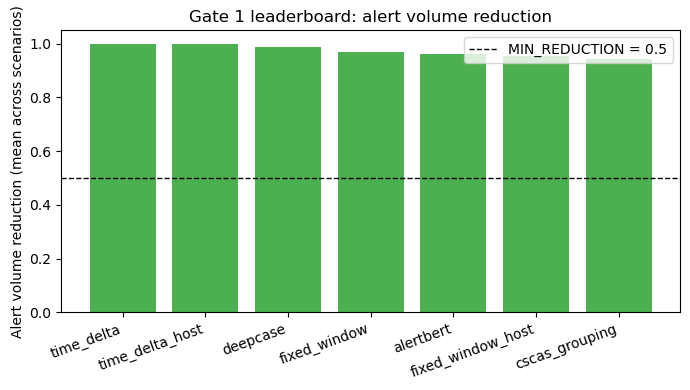

,method,reduction
0,time_delta,0.999988
1,time_delta_host,0.999295
2,deepcase,0.987140
3,fixed_window,0.970594
4,alertbert,0.962329
5,fixed_window_host,0.953978
6,cscas_grouping,0.944114


In [49]:
if best_settings.empty:
    print("[skip] no results loaded -- run the baseline scripts first")
    gate1_df = pd.DataFrame()
else:
    gate1_df = (
        best_settings.groupby("method", as_index=False)["reduction"]
        .mean()
        .sort_values("reduction", ascending=False)
        .reset_index(drop=True)
    )

    fig, ax = plt.subplots(figsize=(7, 4))
    colors = [
        GATE_PASS_COLOR if v >= MIN_REDUCTION else GATE_FAIL_COLOR
        for v in gate1_df["reduction"]
    ]
    ax.bar(gate1_df["method"], gate1_df["reduction"], color=colors)
    ax.axhline(MIN_REDUCTION, color="black", linestyle="--", linewidth=1,
               label=f"MIN_REDUCTION = {MIN_REDUCTION:g}")
    ax.set_ylabel("Alert volume reduction (mean across scenarios)")
    ax.set_title("Gate 1 leaderboard: alert volume reduction")
    ax.set_xticklabels(gate1_df["method"], rotation=20, ha="right")
    ax.legend()
    plt.tight_layout()
    plt.show()

gate1_df


### 10.2 Gate 2 -- Group purity

Does grouping preserve the signal a downstream system needs, or does it
dilute attacks into benign noise? Three separate leaderboards, since these
three metrics can disagree with each other (e.g. a method can have a low
mixed-group fraction but still leak minority-class alerts into the groups
that remain).


/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_68805/1748692802.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(sub["method"], rotation=20, ha="right")
/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_68805/1748692802.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(sub["method"], rotation=20, ha="right")
/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_68805/1748692802.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(sub["method"], rotation=20, ha="right")


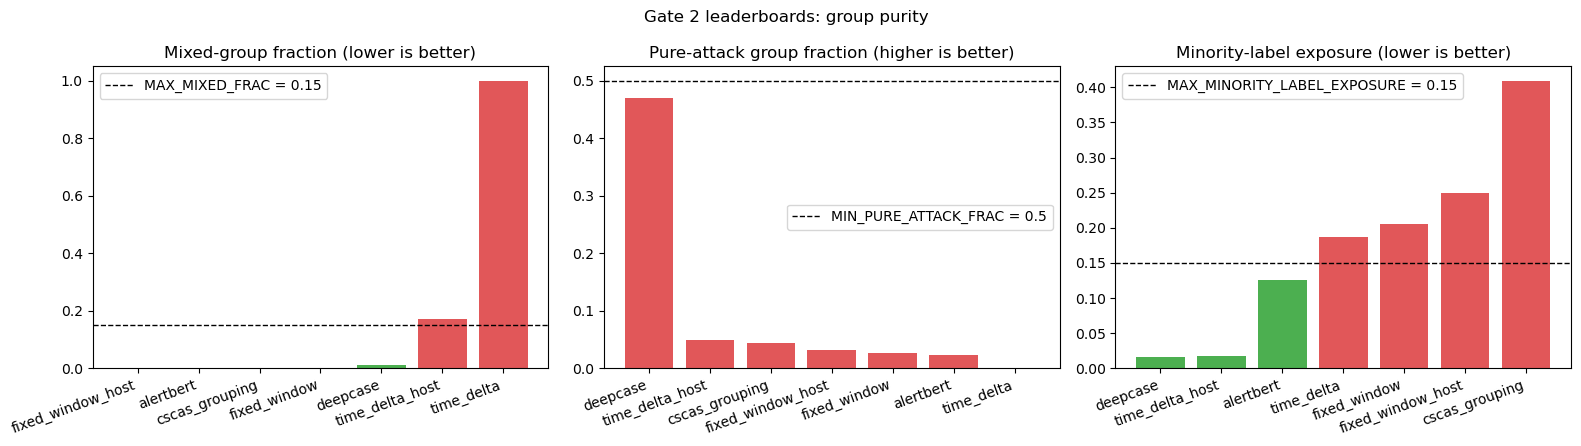

,method,mixed_frac,pure_attack_frac,minority_label_exposure
0,alertbert,0.000214,0.023669,0.125000
1,cscas_grouping,0.000526,0.043809,0.409420
2,deepcase,0.011772,0.470198,0.015460
3,fixed_window,0.000568,0.026125,0.204762
4,fixed_window_host,0.000139,0.031419,0.250000
5,time_delta,1.000000,0.000000,0.186281
6,time_delta_host,0.172281,0.048421,0.017078


In [50]:
if best_settings.empty:
    print("[skip] no results loaded -- run the baseline scripts first")
    gate2_df = pd.DataFrame()
else:
    gate2_df = best_settings.groupby("method", as_index=False)[
        ["mixed_frac", "pure_attack_frac", "minority_label_exposure"]
    ].mean()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    # Lower is better
    sub = gate2_df.sort_values("mixed_frac")
    colors = [GATE_PASS_COLOR if v <= MAX_MIXED_FRAC else GATE_FAIL_COLOR for v in sub["mixed_frac"]]
    axes[0].bar(sub["method"], sub["mixed_frac"], color=colors)
    axes[0].axhline(MAX_MIXED_FRAC, color="black", linestyle="--", linewidth=1,
                     label=f"MAX_MIXED_FRAC = {MAX_MIXED_FRAC:g}")
    axes[0].set_title("Mixed-group fraction (lower is better)")
    axes[0].set_xticklabels(sub["method"], rotation=20, ha="right")
    axes[0].legend()

    # Higher is better
    sub = gate2_df.sort_values("pure_attack_frac", ascending=False)
    colors = [GATE_PASS_COLOR if v >= MIN_PURE_ATTACK_FRAC else GATE_FAIL_COLOR for v in sub["pure_attack_frac"]]
    axes[1].bar(sub["method"], sub["pure_attack_frac"], color=colors)
    axes[1].axhline(MIN_PURE_ATTACK_FRAC, color="black", linestyle="--", linewidth=1,
                     label=f"MIN_PURE_ATTACK_FRAC = {MIN_PURE_ATTACK_FRAC:g}")
    axes[1].set_title("Pure-attack group fraction (higher is better)")
    axes[1].set_xticklabels(sub["method"], rotation=20, ha="right")
    axes[1].legend()

    # Lower is better
    sub = gate2_df.sort_values("minority_label_exposure")
    colors = [GATE_PASS_COLOR if v <= MAX_MINORITY_LABEL_EXPOSURE else GATE_FAIL_COLOR for v in sub["minority_label_exposure"]]
    axes[2].bar(sub["method"], sub["minority_label_exposure"], color=colors)
    axes[2].axhline(MAX_MINORITY_LABEL_EXPOSURE, color="black", linestyle="--", linewidth=1,
                     label=f"MAX_MINORITY_LABEL_EXPOSURE = {MAX_MINORITY_LABEL_EXPOSURE:g}")
    axes[2].set_title("Minority-label exposure (lower is better)")
    axes[2].set_xticklabels(sub["method"], rotation=20, ha="right")
    axes[2].legend()

    fig.suptitle("Gate 2 leaderboards: group purity")
    plt.tight_layout()
    plt.show()

gate2_df


### 10.3 Gate 3 -- Cross-scenario generalization

A method that performs very differently on `fox` vs `russellmitchell` is a
risky drop-in even if its average looks good -- it suggests the operating
point is tuned to one attack pattern rather than genuinely transferable.
Ranked on the absolute gap in reduction between the two scenarios (smaller
is better).

Because `best_settings` (section 9) now uses one jointly-best param per
method rather than two independently-tuned per-scenario params, this gap
is guaranteed to compare the *same* configuration's reduction across
scenarios -- it measures genuine cross-scenario transfer, not two
different operating points that each happened to be near their own
scenario's ceiling.


/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_68805/526120169.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(gate3_df["method"], rotation=20, ha="right")


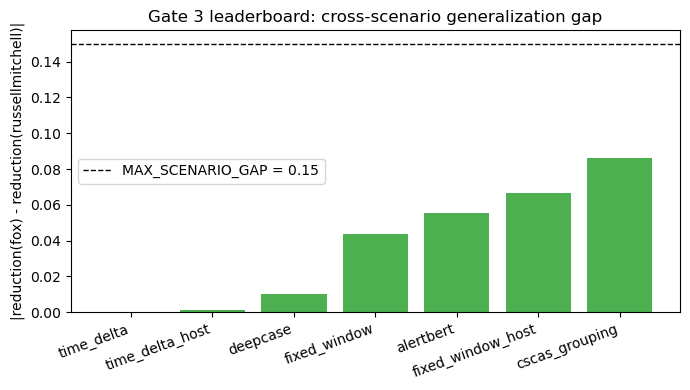

,method,gap
0,time_delta,0.000020
1,time_delta_host,0.001093
2,deepcase,0.010025
3,fixed_window,0.043682
4,alertbert,0.055608
5,fixed_window_host,0.066439
6,cscas_grouping,0.086015


In [51]:
if best_settings.empty:
    print("[skip] no results loaded -- run the baseline scripts first")
    gate3_df = pd.DataFrame()
else:
    pivot_reduction = best_settings.pivot(index="method", columns="scenario", values="reduction")
    gate3_df = pd.DataFrame({"method": pivot_reduction.index})
    gate3_df["gap"] = (pivot_reduction["fox"] - pivot_reduction["russellmitchell"]).abs().values
    gate3_df = gate3_df.sort_values("gap").reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(7, 4))
    colors = [GATE_PASS_COLOR if v <= MAX_SCENARIO_GAP else GATE_FAIL_COLOR for v in gate3_df["gap"]]
    ax.bar(gate3_df["method"], gate3_df["gap"], color=colors)
    ax.axhline(MAX_SCENARIO_GAP, color="black", linestyle="--", linewidth=1,
               label=f"MAX_SCENARIO_GAP = {MAX_SCENARIO_GAP:g}")
    ax.set_ylabel("|reduction(fox) - reduction(russellmitchell)|")
    ax.set_title("Gate 3 leaderboard: cross-scenario generalization gap")
    ax.set_xticklabels(gate3_df["method"], rotation=20, ha="right")
    ax.legend()
    plt.tight_layout()
    plt.show()

gate3_df


In [ ]:
# LaTeX -- section 10 gate leaderboards (Gate 1-3). Needs \usepackage{booktabs}.
_gate_latex = [
    (gate1_df, ["method", "reduction"], "tab:grouping-gate1",
     "Gate 1 leaderboard --- alert-volume reduction at each method's "
     "jointly-best setting, mean across scenarios."),
    (gate2_df, ["method", "mixed_frac", "pure_attack_frac", "minority_label_exposure"],
     "tab:grouping-gate2",
     "Gate 2 leaderboard --- group purity at each method's jointly-best "
     "setting, mean across scenarios (Mixed / Minority exp.\\ lower is "
     "better; Pure-attack higher is better)."),
    (gate3_df, ["method", "gap"], "tab:grouping-gate3",
     "Gate 3 leaderboard --- absolute reduction gap between \\texttt{fox} "
     "and \\texttt{russellmitchell} at the shared jointly-best setting "
     "(smaller is better)."),
]
for _gdf, _gcols, _glabel, _gcaption in _gate_latex:
    if _gdf is None or _gdf.empty:
        continue
    print(to_latex_table(_gdf[_gcols].set_index("method"), caption=_gcaption,
                         label=_glabel, decimals=4))
    print()

### 10.4 Gate 4 -- Operational fit

Deployment facts that don't show up in any accuracy metric but matter for
whether a method is actually installable in the target system: GPU
requirement, extra dependencies beyond the plain project `venv`, and whether
the method has a rejection/deferral path (an `ungroupable_fraction` > 0 --
only DeepCASE has this, confirmed by the assertion in section 9). Hardcoded
from the environment notes in the notebook's own introduction (cell 1) --
worth double-checking against `run_grouping.sh` / each script's module
docstring before this goes in the thesis.


In [52]:
# Hardcoded from the notebook's own intro cell (env/dependency notes) --
# review before treating as final.
deployment_facts = pd.DataFrame([
    {"method": "fixed_window",   "gpu_required": False, "extra_deps": "none (plain venv)",              "has_rejection_path": False},
    {"method": "time_delta",     "gpu_required": False, "extra_deps": "none (plain venv)",              "has_rejection_path": False},
    {"method": "cscas_grouping", "gpu_required": False, "extra_deps": "none (plain venv)",              "has_rejection_path": False},
    {"method": "alertbert",      "gpu_required": True,  "extra_deps": "separate conda env, graph_tool", "has_rejection_path": False},
    {"method": "deepcase",       "gpu_required": True,  "extra_deps": "torch",                          "has_rejection_path": True},
])

if summary_table is None or summary_table.empty:
    print("[skip] no results loaded -- run the baseline scripts first")
    gate4_df = deployment_facts.copy()
else:
    timing = summary_table[["train_time_seconds", "inference_time_seconds"]].reset_index()
    gate4_df = deployment_facts.merge(timing, on="method", how="left")

gate4_df["passes_operational"] = ~(REQUIRES_NO_REJECTION & gate4_df["has_rejection_path"])
gate4_df = gate4_df.sort_values(
    ["passes_operational", "gpu_required", "train_time_seconds"],
    ascending=[False, True, True],
).reset_index(drop=True)

(
    gate4_df.style
    .apply(lambda col: [f"background-color: {GATE_PASS_COLOR if v else GATE_FAIL_COLOR}" for v in col]
           if col.name == "passes_operational" else [""] * len(col))
)


,method,gpu_required,extra_deps,has_rejection_path,train_time_seconds,inference_time_seconds,passes_operational
0,fixed_window,False,none (plain venv),False,nan,0.186453,True
1,time_delta,False,none (plain venv),False,nan,0.368702,True
2,cscas_grouping,False,none (plain venv),False,nan,0.542742,True
3,deepcase,True,torch,True,175.425784,nan,True
4,alertbert,True,"separate conda env, graph_tool",False,nan,15.790034,True


In [ ]:
# LaTeX -- section 10.4 operational fit. Needs \usepackage{booktabs}.
print(to_latex_table(
    gate4_df.reindex(columns=[
        "method", "gpu_required", "extra_deps", "has_rejection_path",
        "train_time_seconds", "inference_time_seconds", "passes_operational",
    ]).set_index("method"),
    caption=(
        "Gate 4 --- operational fit: deployment facts (from the notebook "
        "intro) plus measured train / inference time. \\emph{Op.\\ fit} is "
        "false only when \\texttt{REQUIRES\\_NO\\_REJECTION} and the method "
        "has a rejection path."
    ),
    label="tab:grouping-gate4",
    decimals=2,
))

## 11. Final integration scorecard

Everything from section 10 combined into a single pass/fail table, with all
four gates applied together. This is the table the "fittable drop-in"
argument rests on: it isn't the highest-reduction method, or the purest
method, in isolation -- it's whichever method(s) clear every gate
simultaneously.


In [53]:
if best_settings.empty or gate1_df.empty:
    print("[skip] no results loaded -- run the baseline scripts first")
    scorecard = pd.DataFrame()
else:
    scorecard = gate1_df.rename(columns={"reduction": "reduction_mean"})
    scorecard["passes_reduction"] = scorecard["reduction_mean"] >= MIN_REDUCTION

    scorecard = scorecard.merge(gate2_df, on="method")
    scorecard["passes_purity"] = (
        (scorecard["mixed_frac"] <= MAX_MIXED_FRAC)
        & (scorecard["pure_attack_frac"] >= MIN_PURE_ATTACK_FRAC)
        & (scorecard["minority_label_exposure"] <= MAX_MINORITY_LABEL_EXPOSURE)
    )

    scorecard = scorecard.merge(gate3_df, on="method")
    scorecard["passes_generalization"] = scorecard["gap"] <= MAX_SCENARIO_GAP

    scorecard = scorecard.merge(
        gate4_df[["method", "gpu_required", "extra_deps", "has_rejection_path", "passes_operational"]],
        on="method",
    )

    gate_cols = ["passes_reduction", "passes_purity", "passes_generalization", "passes_operational"]
    scorecard["n_gates_passed"] = scorecard[gate_cols].sum(axis=1)
    scorecard["verdict"] = np.where(
        scorecard[gate_cols].all(axis=1), "candidate", "eliminated"
    )

    scorecard = scorecard.sort_values(
        ["verdict", "n_gates_passed", "reduction_mean"], ascending=[True, False, False]
    ).reset_index(drop=True)

    candidates = scorecard.loc[scorecard["verdict"] == "candidate", "method"].tolist()
    if candidates:
        print(f"Candidates surviving all four gates: {candidates}")
    else:
        print("No method survives all four gates at the current thresholds -- "
              "revisit thresholds or consider a hybrid/fallback strategy.")

display_cols = ["method", "reduction_mean", "passes_reduction",
                 "mixed_frac", "pure_attack_frac", "minority_label_exposure", "passes_purity",
                 "gap", "passes_generalization",
                 "gpu_required", "extra_deps", "has_rejection_path", "passes_operational",
                 "n_gates_passed", "verdict"]

(
    scorecard[display_cols].style
    .apply(lambda col: [f"background-color: {GATE_PASS_COLOR if v else GATE_FAIL_COLOR}" for v in col]
           if col.name.startswith("passes_") else [""] * len(col))
    .apply(lambda col: [f"background-color: {GATE_PASS_COLOR if v == 'candidate' else GATE_FAIL_COLOR}" for v in col]
           if col.name == "verdict" else [""] * len(col))
)


No method survives all four gates at the current thresholds -- revisit thresholds or consider a hybrid/fallback strategy.


,method,reduction_mean,passes_reduction,mixed_frac,pure_attack_frac,minority_label_exposure,passes_purity,gap,passes_generalization,gpu_required,extra_deps,has_rejection_path,passes_operational,n_gates_passed,verdict
0,time_delta,0.999988,True,1.000000,0.000000,0.186281,False,0.000020,True,False,none (plain venv),False,True,3,eliminated
1,deepcase,0.987140,True,0.011772,0.470198,0.015460,False,0.010025,True,True,torch,True,True,3,eliminated
2,fixed_window,0.970594,True,0.000568,0.026125,0.204762,False,0.043682,True,False,none (plain venv),False,True,3,eliminated
3,alertbert,0.962329,True,0.000214,0.023669,0.125000,False,0.055608,True,True,"separate conda env, graph_tool",False,True,3,eliminated
4,cscas_grouping,0.944114,True,0.000526,0.043809,0.409420,False,0.086015,True,False,none (plain venv),False,True,3,eliminated


In [ ]:
# LaTeX -- section 11 integration scorecard. Needs \usepackage{booktabs} and
# \usepackage{graphicx} (for \resizebox). GPU / dependency / rejection-path
# columns are dropped here -- they're in the Gate 4 table.
if not scorecard.empty:
    print(to_latex_table(
        scorecard.reindex(columns=[
            "method", "reduction_mean", "passes_reduction",
            "mixed_frac", "pure_attack_frac", "minority_label_exposure", "passes_purity",
            "gap", "passes_generalization", "passes_operational",
            "n_gates_passed", "verdict",
        ]).set_index("method"),
        caption=(
            "Final integration scorecard: all four gates applied together. "
            "GPU / dependency / rejection-path detail is in "
            "Table~\\ref{tab:grouping-gate4}."
        ),
        label="tab:grouping-scorecard",
        resizebox=True,
        decimals=4,
    ))

In [54]:
scorecard.to_csv("grouping_integration_scorecard.csv", index=False)
